In [8]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt
from ruptures.metrics import precision_recall


Now i will be using my new knowledge from https://www.lancaster.ac.uk/~romano/teaching/2425MATH337/5_real_data.html to work on real world data.

See [Notes.md](Notes.md) for the parametric vs. non-parametric methods theory.

Generate some time series without changes (e.g., using numpy.random.standard_normal). How big do you have to select the penalties to be such that for some series of length n, your probability of it incorrectly adding in a change is below some threshold. Do this for a non parametric method, such as PELT with the cost set as RBF, and for pelt with it set up to detect changes in mean, and variance

Detected breakpoints: [250, 490, 495, 760, 1000]
Detected breakpoints: [250, 490, 495, 760, 1000]
Detected breakpoints: [125, 130, 190, 200, 245, 250, 490, 495, 675, 680, 760, 765, 995, 1000]
True breakpoints: [249, 493, 760, 1000]


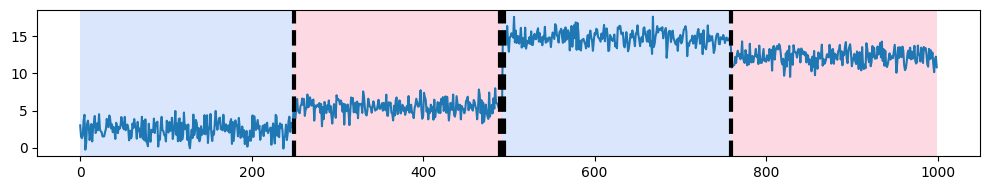

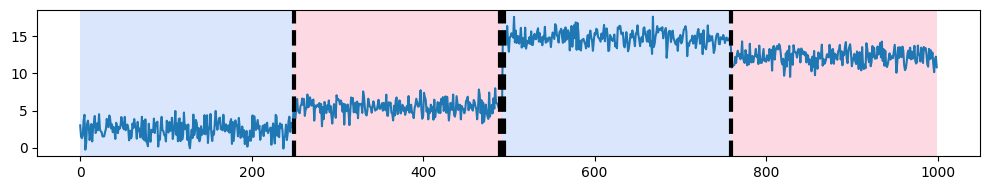

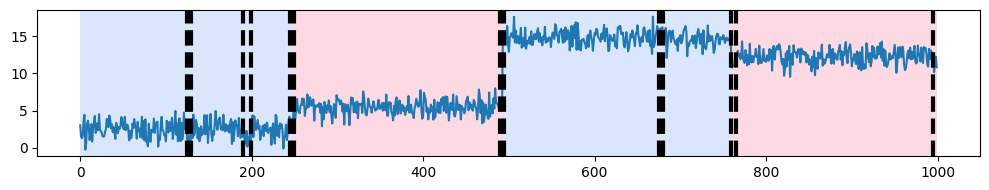

In [18]:
# We generate samples with a piecewise constant signal
n_samples, dim, sigma = 1000, 1, 1
n_bkps = 3  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="l2").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=2 *np.log(n_samples))
result2 = algo.predict(pen=3 *np.log(n_samples))
result3 = algo.predict(pen=2 * 2)
# Display
rpt.display(signal, bkps, result1) 
rpt.display(signal, bkps, result2)
rpt.display(signal, bkps, result3)
print("Detected breakpoints:", result1)
print("Detected breakpoints:", result2)
print("Detected breakpoints:", result3) 
print("True breakpoints:", bkps)

# 
plt.show()



Here you can see I used the PELT algorthimn for finding a piecewise linear function, however as we can see according to literature that out MBIC performed most acurately for our project 

Now doing this again but this time for non-parametric methods we can see even 


Detected breakpoints: [400, 620, 800, 1000]
True breakpoints: [199, 399, 618, 799, 1000]


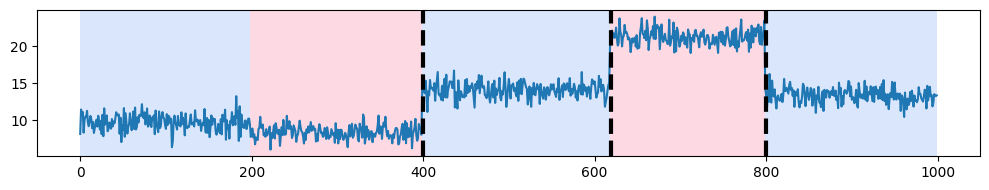

In [19]:
n_samples, dim, sigma = 1000, 1, 1
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=3 *np.log(n_samples))

# Display
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)

# 
plt.show()

For the next part of the task I will execute a test using MC simulation trying to find which values of N have the lowest value of alpha or false detection rate 


In [31]:
import numpy as np
import pandas as pd
import ruptures as rpt

n_samples = 300
n_trials = 500  # number of noise series simulated per (model, penalty) cell

model = ["rbf", "l1", "l2", "normal"]
tests = [np.log(n_samples), 2 * np.log(n_samples), 3 * np.log(n_samples), 4 * np.log(n_samples)]
test_labels = ["1×log(n)", "2×log(n)", "3×log(n)", "4×log(n)"]

results = pd.DataFrame(index=test_labels, columns=model, dtype=float)

for m in model:
    for label, pen in zip(test_labels, tests):
        false_positives = 0
        for _ in range(n_trials):
            signal = np.random.standard_normal(n_samples)
            algo = rpt.Pelt(model=m).fit(signal)
            predicted = algo.predict(pen=pen)
            if len(predicted) > 1:  # more than just the end-of-series marker = a false breakpoint
                false_positives += 1
        results.loc[label, m] = false_positives / n_trials

results


/Users/valeriysinko/Library/Python/3.9/lib/python/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


,rbf,l1,l2,normal
1×log(n),0.0,0.03,0.352,0.938
2×log(n),0.0,0.00,0.020,0.138
3×log(n),0.0,0.00,0.000,0.006
4×log(n),0.0,0.00,0.000,0.000


Where we can see here that rbf being the best results giving 0 regardless of the of the penalty,
this is because in rbf we use the kernel trick and why we use it can be found in [Notes.md](Notes.md).

$RBF explanation-kernel based$
$$
c_{rbf}(y_{a..b}) := (b-a) - \frac{1}{b-a}\sum_{s,t=a+1}^{b} \exp\left(-\gamma \|y_s - y_t\|^2\right) \tag{C12}
$$

*where $\gamma > 0$ is the so-called bandwidth parameter.*
and it is so effective as there is a sharp increase.
If points are close together $\|y_s - y_t\|^2$ is small so the exponent value is 1 take from taylor expansion contributing almost nothing to extra cost. Once it exceeds $\frac{1}{\gamma}$ then it collapses it collapses towards 0 so therefore it increases and increases against our penalty threshold adding a new time
and when they e.g. 
if $y_n = 1. \ y_{n+1} = 5$ then the cost will be 4 and notify a change point

**MLE Based** - L2
MLE is a type of parametric model of inference which 
$$c_{L2}(y_{a..b}) := \sum_{t=a+1}^{b} \left\| y_t - \bar{y}_{a..b} \right\|_2^2$$

and the way that it links back to the maximum-likelihood link is the following:

**Maximizing over μ**

The first term doesn't involve $\mu$ at all, so maximizing $\ell(\mu)$ is exactly
equivalent to minimizing $\sum_{t=a+1}^{b} (y_t - \mu)^2$. Taking the derivative
and setting it to zero:

$$
\frac{d}{d\mu}\sum_{t=a+1}^{b}(y_t-\mu)^2
= -2\sum_{t=a+1}^{b}(y_t - \mu) = 0
\quad\Longrightarrow\quad
\hat\mu_{\text{MLE}} = \bar y_{a..b}
$$

So the MLE of the segment mean is just the empirical mean — unsurprising, but
the useful part is plugging it back in.

**Plugging the MLE back into the (negative) log-likelihood**

$$
-2\ell(\hat\mu_{\text{MLE}})
= (b-a)\log(2\pi\sigma^2)
+ \frac{1}{\sigma^2}\sum_{t=a+1}^{b}\left(y_t - \bar y_{a..b}\right)^2
$$

The second term, up to the constant $1/\sigma^2$, is exactly:

$$
c_{L2}(y_{a..b}) = \sum_{t=a+1}^{b} \left\| y_t - \bar y_{a..b} \right\|_2^2
$$

and take off the scaling factor where minimisation lands and we get our answer


So what are the similarities and difference between MLEs and Kernel methods, both in a sense measure some distance in order to get our values. 
**Assumptions** 
Assumes there is a distribution, rbf doesnt assume any dsitribution.
**Normmalisaion**
MLE must be normalised howeve Kernel methods do not
**Speed** 

$C_{L2}$ is cheap and has a $O(n)$ time as it solves it linearl, while 

**Divergence** both attain a $n^{-1/2}$ scale error 

$RBF$ is expensive, as we need to calculate the Gram matrix for every pair inside the segment so $O(n^2)$ all at once
MLEs such as L2 have a complexit of $O(n)$ per cumaltive sum

RBF is a characteristic kernel/ however the fisher kernel is not garenteed to be charactertic and when plugged into the loss function it doesnt always equal to the cost function

Both dont take into consideration temporal dependence however, if how you observe the data effects your results



**To Do**: Then start to introduce some changes into the time series. Rescale the samples you have drawn so that you can change the variance, or add to the series. Keep a penalty that you had from before which maintains some reasonably low false positive rate.

with given std 2
Detected breakpoints: [405, 605, 810, 1000]
True breakpoints: [197, 405, 606, 811, 1000]


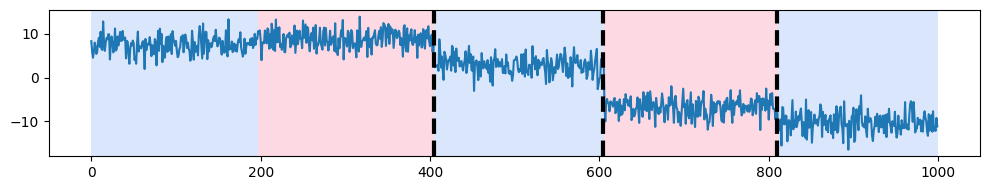

with given std 5
Detected breakpoints: [405, 1000]
True breakpoints: [203, 403, 604, 790, 1000]


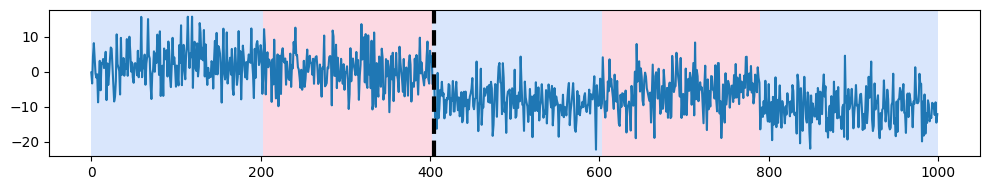

with given std 7
Detected breakpoints: [390, 1000]
True breakpoints: [180, 392, 606, 803, 1000]


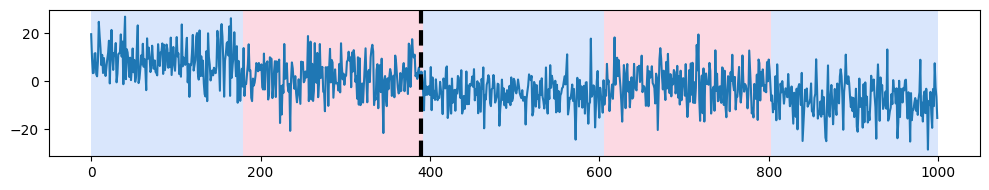

with given std 9
Detected breakpoints: [395, 1000]
True breakpoints: [200, 396, 609, 811, 1000]


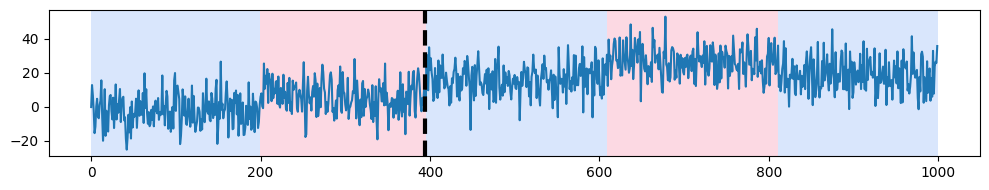

In [24]:
n_samples, dim, sigma = 1000, 1, 2
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=3 *np.log(n_samples))

# Display
print(f'with given std {sigma}')
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)

# 
plt.show()

n_samples, dim, sigma = 1000, 1, 5
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=3 *np.log(n_samples))

# Display
print(f'with given std {sigma}')
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)

# 
plt.show()

n_samples, dim, sigma = 1000, 1, 7
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=3 *np.log(n_samples))

# Display
print(f'with given std {sigma}')
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)

# 
plt.show()

n_samples, dim, sigma = 1000, 1, 9
n_bkps = 4  # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen=3 *np.log(n_samples))

# Display
print(f'with given std {sigma}')
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)

# 
plt.show()

Here we can clearly see as SD increases our changepoint detections clearly become worse and worse, till it can barely detect any sort of change points we may be having.

Now I will check that the method wont halucinate breakpoints,

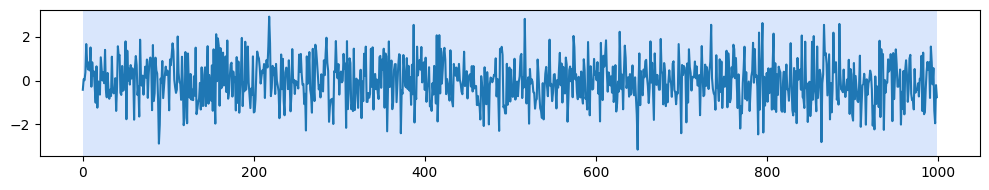

Detected breakpoints: [1000]
True breakpoints: [1000]


In [27]:
n_samples = 1000
signal = np.random.standard_normal(n_samples)
true_bkps = [n_samples]  # no real change — ruptures convention: last index marks end of series

algo = rpt.Pelt(model="rbf").fit(signal)
predict = algo.predict(pen=3 * np.log(n_samples))

rpt.display(signal, true_bkps, predict)
plt.show()

print("Detected breakpoints:", predict)
print("True breakpoints:", true_bkps)


This showing this, as we increase variance, total amount of break points of false detection also increase, we can calculate this as well.

**Next Task**


Think about how each method is doing, on time series which may contain multiple changes. How could you score the performance of each method? what are some sensible performance metrics which you could use to compare their performances

See [Notes.md](Notes.md) for the theory on segmentation accuracy metrics (F1, Rand Index, Hausdorff distance). I will be using this new found information later!

These metrics specialise in different definitions of what "good" is we go case by cause,
The Hausdorff index is a measure of the supremum distance and doesnt tell us anything about how good the detection is,therefore it is partually useful, it tells us more about the reliability of our choices of break points.

Randindex is good as it is parameters free and we dont need to have any labels, however in rand you get points if you are in the same segment and different segments, most of the time this is true therefore inflating the score. In ARI it assumes a level of luck which is too low, therefore making every score look better than it should be

The best metric being the F1 score as it allows us to take a radius around the point and calculate it based on this being a hollistic approch to the manner

Here I will show you it now.

with given std 3
Detected breakpoints: [120, 380, 495, 615, 745, 1000]
True breakpoints: [121, 256, 379, 497, 618, 746, 870, 1000]
P: 1.000  R: 0.714  F1: 0.833  K_hat: 5 vs 7


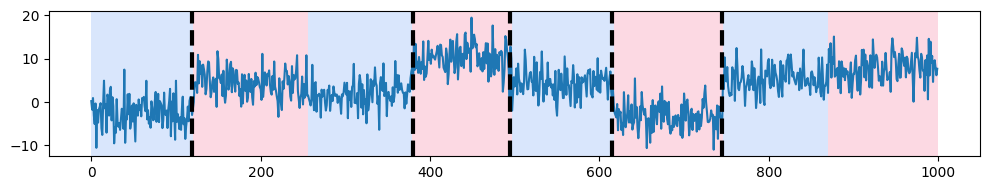

In [41]:
n_samples, dim, sigma = 1000, 1, 3
n_bkps = 7 # number of breakpoints
signal, bkps = rpt.pw_constant(n_samples, dim, n_bkps, noise_std=sigma)

algo = rpt.Pelt(model="rbf").fit(signal)
#Using the BIC penalty to select the number of breakpoints which we can see is roughly correct
result1 = algo.predict(pen= 4*np.log(n_samples))

# Display
print(f'with given std {sigma}')
rpt.display(signal, bkps, result1) 
print("Detected breakpoints:", result1)
print("True breakpoints:", bkps)
p, r = precision_recall(bkps, result1, margin=5)
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
print(f"P: {p:.3f}  R: {r:.3f}  F1: {f1:.3f}  K_hat: {len(result1)-1} vs {n_bkps}")

---
**Next Question**



Do we want to design our own tests (e.g., some simple two sample test, where we only look for a single change), so we can create identical methods to compare these choices for cost functions together? Or shall we use an existing implementation of these things. There are pros and cons to each.

**What defines a good test**

A test is defined as being something that reduces the data into a single number that allows us to perform a hypothesis. A test statistic is selected as a way to perform the hypothesis test and test statistics are selected in a way to quantify, behaviours to distinguished the null and alternative hypothesis and  allows p-values to be calculated.




**My Test Setup**


I will do N simulations of whatever change point occurring at a random T, and see, with this changepoint, if RBF/L2 can successfully differentiate between the 2. If it can, add a point; if not, don't add a point — whereby at the end of it we will have a value for the true positive rate at that specific effect size. Our effect size being 0.05.

My penalty function will be calculated via simulation, and we will take the value of the cost function where it will take the max reduction function against all values.

Taking values not at edge cases, so reading off 95% as the weighing of T(n-T)/n weight coming from the L2 loss and also RBF. Seen in the formula of:
$$
\text{L2 reduction} = \frac{\tau(n-\tau)}{n} \left( \bar{y}_L - \bar{y}_R \right)^2
$$
$$
\text{RBF reduction} = \frac{\tau(n-\tau)}{n} \, \widehat{\text{MMD}}^2_{L,R}
$$
---
**Issues**



Issues with my test that I have: Gamma is re-estimated per series, so different null hypothesis per series.

This test is standardised on normalised data, so when it's not this in real, like such as a variance shift or t3 series, it will break.

In relation to finance, it assumes all variables are IID; however, in reality it is far from the truth — this being that a lot of the times we get clustering around regions.

possible fix to this is through bootstrapping contiguous blocks of real world data

- possible fix to this is through bootstrapping contingous blocks of real world data

- median heuristics computes gamma by taking all points, computing squared distances between each pair and taking the median of those distances setting it as 1/median (sqr distance) as gamma

---
**Possible Improvements** TLDR

- Fix gamma values 

- Before analysing the data regardless of what it is I could standardise by finding the sample mean and sample standard deviation of it.
- Block bootstrapping

- Compare our results with the NP test as its the fundamental ceiling ??? look into it





**Question:**
How should we decide how to tune the penalty for adding in a changepoint in each setting? Suppose we decide to consider time series of fixed length, e.g., 2000. What sensible ways are there to tune the penalty value, beta, by simulation.


For our test, because AMOC fixes the number of changepoints to one, we cannot use a model like the elbow plot or CROPS but instead we must find a threshold value. We instead can find the value or threshold via simulation we will find the cost reduction of the 95% percentile of all changes to find our beta value

Here is some simulation code we can use to help us in the answer

I should have used a prebuilt package such as binseg with 1 breakpoint, regardless lol

In [49]:
n, B, alpha, min_size = 500, 2000, 0.05,25
rng = np.random.default_rng(0)


#This function computes maximum cost across all values and does consider edge cases so power is not overestimated.
#This returns max cost from a single split
def amoc(y, cost):
    """Max cost reduction from a single split."""
    c = cost.fit(y)
    whole = c.error(0, len(y))
    taus = np.arange(min_size, len(y) - min_size + 1)
    return max(whole - (c.error(0, t) + c.error(t, len(y))) for t in taus)


T = {"L2": [], "RBF": []}
#This calculates the thresholds for L2 and RBF based on multiple simulations
for _ in range(B):
    y = rng.standard_normal(n)
    T["L2"].append(amoc(y, rpt.costs.CostL2()))
    T["RBF"].append(amoc(y, rpt.costs.CostRbf()))

#This takes the 95th percentile of each cost distribution to set penality thresholds 
c_hat = {k: np.quantile(v, 1 - alpha) for k, v in T.items()}
print("thresholds:", {k: round(float(v), 3) for k, v in c_hat.items()})
#This checks that thresholds exceed 5% of time on fresh nulls
hits = {"L2": 0, "RBF": 0}
for _ in range(500):
    y = rng.standard_normal(n)
    hits["L2"]  += amoc(y, rpt.costs.CostL2()) > c_hat["L2"]
    hits["RBF"] += amoc(y, rpt.costs.CostRbf()) > c_hat["RBF"]
print("attained size:", {k: float(v) / 500 for k, v in hits.items()})

thresholds: {'L2': 9.395, 'RBF': 2.826}
attained size: {'L2': 0.044, 'RBF': 0.056}


**Questions Asked:**
**Week 3 question 3**

What types of change are interesting for us to look at? We know our kernel methods are sensitive to any type. How much power do likelihood based methods lose if they are looking for a change in gaussian mean, and it turns out to be a change in mean of a different distribution? 

---
Statistical test V1
---


In [58]:
#Maxdrawdown is taken from the value above

#Our changes we will be measuring   
n, B, N, alpha, min_size = 500, 2000, 500, 0.05, 25
rng = np.random.default_rng(0)

def null_gaussian(n, rng):
    """Generate a Gaussian series of length n."""
    return rng.standard_normal(n) 

def mean_shift(n, tau, shift,rng):
    """Generate a Gaussian series of length n with a mean shift at point tau."""
    y = rng.standard_normal(n) 
    y[tau:] += shift
    return y

def variance_shift(n, tau, shift,rng):
    """Generate a Gaussian series of length n with a variance shift at point tau."""
    y = rng.standard_normal(n) 
    y[tau:] *= shift
    return y

def mean_and_variance_shift(n, tau, mean_shift, var_shift,rng):
    """Generate a Gaussian series of length n with a mean and variance shift at point tau."""
    y = rng.standard_normal(n) 
    y[tau:] = var_shift*y[tau:] + mean_shift
    return y

# for our change in distrubutoin we will go from a gaussian to 
def change_in_distr_t(n, tau, df, rng):
    y = rng.standard_normal(n)
    y[tau:] = rng.standard_t(df, n - tau) * np.sqrt((df - 2) / df)
    return y

def rate(gen, N=500, **kw):
    hits = {"L2": 0, "RBF": 0}
    for _ in range(N):
        tau = int(rng.integers(min_size, n - min_size + 1))
        y = gen(n=n, tau=tau, rng=rng, **kw)
        hits["L2"]  += amoc(y, rpt.costs.CostL2())  > c_hat["L2"]
        hits["RBF"] += amoc(y, rpt.costs.CostRbf()) > c_hat["RBF"]
    return {k: v / N for k, v in hits.items()}

rows = [("mean 0.4",  mean_shift,               dict(shift=0.4)),
        ("var 1.6",   variance_shift,           dict(shift=1.6)),
        ("mean+var",  mean_and_variance_shift,  dict(mean_shift=0.4, var_shift=1.5)),
        ("t3",        change_in_distr_t,        dict(df=3)),
        ("t5",        change_in_distr_t,        dict(df=5))]

print(f"{'scenario':<12}{'L2':>8}{'RBF':>8}")
print("-" * 28)
for label, gen, kw in rows:
    r = rate(gen, **kw)
    print(f"{label:<12}{r['L2']:>8.3f}{r['RBF']:>8.3f}")

scenario          L2     RBF
----------------------------
mean 0.4       0.838   0.694
var 1.6        0.306   0.846
mean+var       0.852   0.874
t3             0.042   0.684
t5             0.062   0.128


This being a very basic, barebones test which I am going to be adding to over the following weeks.


**Question**

A short list of the types of changes we have interest in finding would be good. Also, univariate or mulitivariate? 


- mean
- variance 
- distribution change / t test, cauchy distribution?
- mean + variance change
- test against correlation/ clustering e.g. (garch),
     - this violated the IID principle and related to real world markets
- gradual ramp instead of a step,
- Skewness



For Univariate vs Multivariate, I believe that observations for multivariate is better as it decreases the chances of a false positive, this works when looking at markets such as the SNP 500 and other stocks, even though it can miss localised changes in the individual stocks, in addition to the O(n) of pelt scales with dimensions and curse of dimensionality.

We would also have to take into consideration the RBF bandwidth as it becomes more difficult to compute the heuristic median due to outliers.

In addition we have to pay attention to the length of our segments more importantly to ensure we dont overfit the noise, e.g. 20-60 days

thresholds: {'L2': 18.756, 'RBF': 1.57}
Mean shift power (multidimensional)
          L2    RBF
value              
0.1    0.218  0.162
0.2    0.726  0.674
0.4    0.990  0.986
0.6    1.000  1.000
0.8    1.000  1.000

Variance shift power (multidimensional)
          L2    RBF
value              
1.2    0.262  0.628
1.4    0.440  0.970
1.6    0.710  0.986
1.8    0.874  0.998
2.0    0.922  1.000


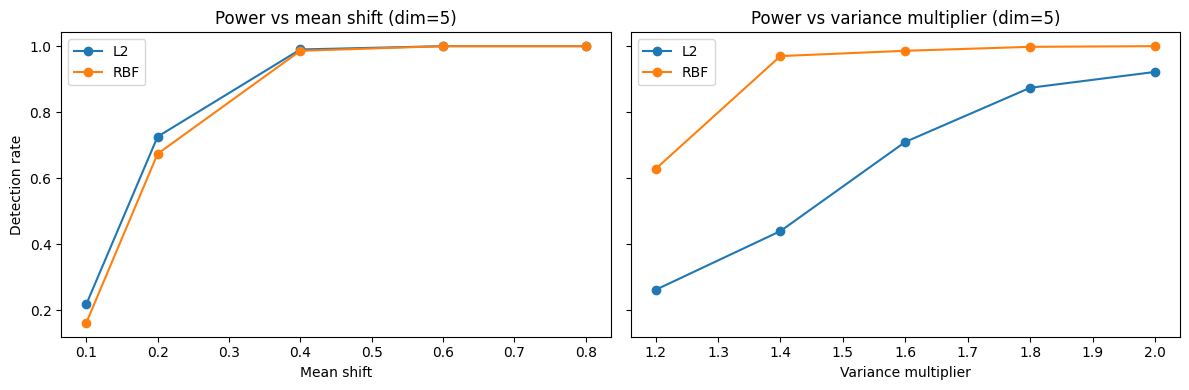

In [62]:
dim = 5
shift_values = [0.1, 0.2, 0.4, 0.6, 0.8]
var_values = [1.2, 1.4, 1.6, 1.8, 2.0]

def amoc(y, cost):
    """Max cost reduction from a single split."""
    c = cost.fit(y)
    whole = c.error(0, len(y))
    taus = np.arange(min_size, len(y) - min_size + 1)
    return max(whole - (c.error(0, t) + c.error(t, len(y))) for t in taus)


T = {"L2": [], "RBF": []}
#This calculates the thresholds for L2 and RBF based on multiple simulations
for _ in range(B):
    y = rng.multivariate_normal(np.zeros(dim), np.eye(dim), size=n)
    T["L2"].append(amoc(y, rpt.costs.CostL2()))
    T["RBF"].append(amoc(y, rpt.costs.CostRbf()))

#This takes the 95th percentile of each cost distribution to set penality thresholds 
c_hat = {k: np.quantile(v, 1 - alpha) for k, v in T.items()}
print("thresholds:", {k: round(float(v), 3) for k, v in c_hat.items()})
#This checks that thresholds exceed 5% of time on fresh nulls

def null_gaussian(n, dim, rng):
    mean = np.zeros(dim)
    cov = np.eye(dim)
    return rng.multivariate_normal(mean, cov, size=n)

def mean_shift(n, tau, shift, rng, dim=2):
    y = rng.multivariate_normal(np.zeros(dim), np.eye(dim), size=n)
    y[tau:] += shift
    return y

def variance_shift(n, tau, shift, rng, dim=2):
    y = rng.multivariate_normal(np.zeros(dim), np.eye(dim), size=n)
    y[tau:] *= shift
    return y

def power_curve(gen, param_name, values, N=500, dim=2):
    rows = []
    for v in values:
        kw = {param_name: v, "dim": dim}
        r = rate(gen, N=N, **kw)
        rows.append({"value": v, "L2": r["L2"], "RBF": r["RBF"]})
    return pd.DataFrame(rows).set_index("value")

mean_power = power_curve(mean_shift, "shift", shift_values, N=500, dim=dim)
var_power = power_curve(variance_shift, "shift", var_values, N=500, dim=dim)

print("Mean shift power (multidimensional)")
print(mean_power)
print("\nVariance shift power (multidimensional)")
print(var_power)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
mean_power.plot(marker="o", ax=axes[0])
axes[0].set_title(f"Power vs mean shift (dim={dim})")
axes[0].set_xlabel("Mean shift")
axes[0].set_ylabel("Detection rate")

var_power.plot(marker="o", ax=axes[1])
axes[1].set_title(f"Power vs variance multiplier (dim={dim})")
axes[1].set_xlabel("Variance multiplier")

plt.tight_layout()
plt.show()

Mean shift power (multidimensional)
          L2    RBF
value              
0.1    0.220  0.208
0.2    0.752  0.684
0.4    0.996  0.986
0.6    1.000  1.000
0.8    1.000  1.000

Variance shift power (multidimensional)
          L2    RBF
value              
1.2    0.202  0.654
1.4    0.464  0.978
1.6    0.692  1.000
1.8    0.870  1.000
2.0    0.932  1.000


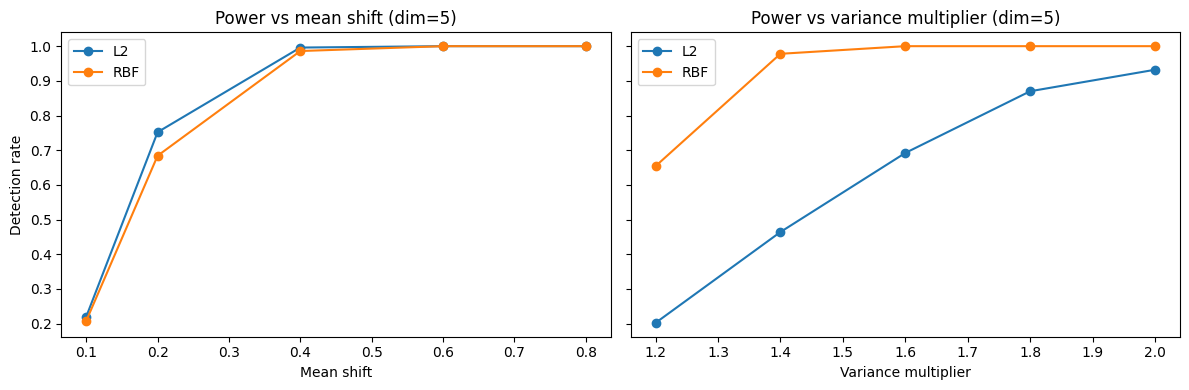

In [63]:
dim = 5
shift_values = [0.1, 0.2, 0.4, 0.6, 0.8]
var_values = [1.2, 1.4, 1.6, 1.8, 2.0]

def null_gaussian(n, dim, rng):
    mean = np.zeros(dim)
    cov = np.eye(dim)
    return rng.multivariate_normal(mean, cov, size=n)

def mean_shift(n, tau, shift, rng, dim=2):
    y = rng.multivariate_normal(np.zeros(dim), np.eye(dim), size=n)
    y[tau:] += shift
    return y

def variance_shift(n, tau, shift, rng, dim=2):
    y = rng.multivariate_normal(np.zeros(dim), np.eye(dim), size=n)
    y[tau:] *= shift
    return y

def power_curve(gen, param_name, values, N=500, dim=2):
    rows = []
    for v in values:
        kw = {param_name: v, "dim": dim}
        r = rate(gen, N=N, **kw)
        rows.append({"value": v, "L2": r["L2"], "RBF": r["RBF"]})
    return pd.DataFrame(rows).set_index("value")

mean_power = power_curve(mean_shift, "shift", shift_values, N=500, dim=dim)
var_power = power_curve(variance_shift, "shift", var_values, N=500, dim=dim)

print("Mean shift power (multidimensional)")
print(mean_power)
print("\nVariance shift power (multidimensional)")
print(var_power)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
mean_power.plot(marker="o", ax=axes[0])
axes[0].set_title(f"Power vs mean shift (dim={dim})")
axes[0].set_xlabel("Mean shift")
axes[0].set_ylabel("Detection rate")

var_power.plot(marker="o", ax=axes[1])
axes[1].set_title(f"Power vs variance multiplier (dim={dim})")
axes[1].set_xlabel("Variance multiplier")

plt.tight_layout()
plt.show()